# NetworkX Basics

## Overview

Networks (graphs) model relationships between entities. In ecology, networks represent stream connectivity, species interactions, dispersal corridors, and monitoring site dependencies.

**Graph types:**

| Type | Directed? | Weighted? | Example |
|---|---|---|---|
| Graph | No | No | Species co-occurrence |
| DiGraph | Yes | No | Upstream-downstream flow |
| MultiGraph | No | Yes | Multiple interaction types |
| DiGraph + weights | Yes | Yes | Stream flow volume |

**Core NetworkX objects:**
- `G.nodes()` / `G.edges()`: node and edge views
- `G.add_node()`, `G.add_edge()`: graph construction
- Node and edge attributes: `G.nodes[n][attr]`, `G.edges[u,v][attr]`
- `nx.to_numpy_array()`: adjacency matrix

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

rng = np.random.default_rng(42)

# Build a stream network: nodes = monitoring sites, edges = flow connections
# Directed: upstream -> downstream
sites = {
    'HEADWATER_A': {'elevation': 350, 'catchment': 'North', 'richness': 22},
    'HEADWATER_B': {'elevation': 320, 'catchment': 'North', 'richness': 19},
    'HEADWATER_C': {'elevation': 280, 'catchment': 'South', 'richness': 24},
    'MID_NORTH':   {'elevation': 210, 'catchment': 'North', 'richness': 17},
    'MID_SOUTH':   {'elevation': 190, 'catchment': 'South', 'richness': 15},
    'CONFLUENCE':  {'elevation': 120, 'catchment': 'Main',  'richness': 14},
    'LOWLAND_A':   {'elevation':  80, 'catchment': 'Main',  'richness': 12},
    'OUTLET':      {'elevation':  40, 'catchment': 'Main',  'richness': 10},
}
flows = [  # (upstream, downstream, flow_m3s)
    ('HEADWATER_A', 'MID_NORTH',  2.1),
    ('HEADWATER_B', 'MID_NORTH',  1.8),
    ('HEADWATER_C', 'MID_SOUTH',  3.2),
    ('MID_NORTH',  'CONFLUENCE',  4.0),
    ('MID_SOUTH',  'CONFLUENCE',  3.5),
    ('CONFLUENCE', 'LOWLAND_A',   7.8),
    ('LOWLAND_A',  'OUTLET',      8.1),
]
G = nx.DiGraph()
for node, attrs in sites.items():
    G.add_node(node, **attrs)
for u, v, flow in flows:
    G.add_edge(u, v, flow=flow)
print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")
print(f"Is DAG (directed acyclic): {nx.is_directed_acyclic_graph(G)}")

Nodes: 8, Edges: 7
Is DAG (directed acyclic): True


---
## Graph Visualisation

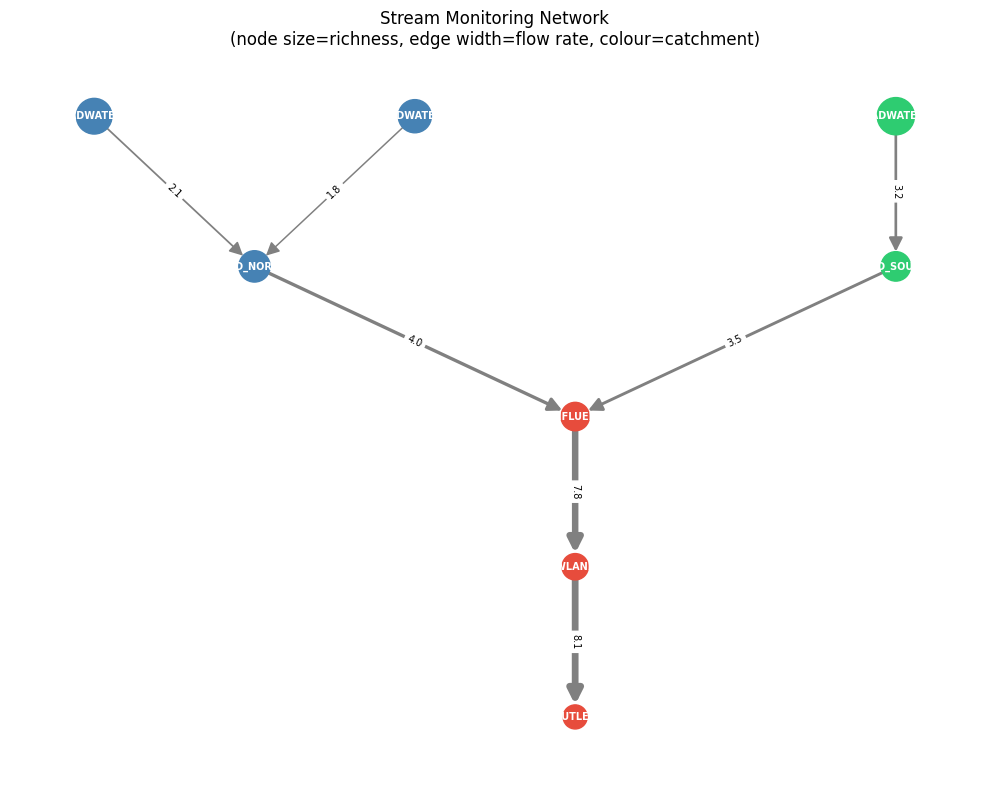

In [2]:
# Hierarchical layout following stream network structure
pos = {
    'HEADWATER_A': (0.5, 4), 'HEADWATER_B': (1.5, 4), 'HEADWATER_C': (3.0, 4),
    'MID_NORTH':   (1.0, 3), 'MID_SOUTH':   (3.0, 3),
    'CONFLUENCE':  (2.0, 2), 'LOWLAND_A':   (2.0, 1), 'OUTLET':      (2.0, 0),
}
richness = [G.nodes[n]['richness'] for n in G.nodes()]
flow_widths = [G.edges[u,v]['flow']*0.6 for u,v in G.edges()]
catchment_colors = {'North':'steelblue','South':'#2ecc71','Main':'#e74c3c'}
node_colors = [catchment_colors[G.nodes[n]['catchment']] for n in G.nodes()]
fig, ax = plt.subplots(figsize=(10, 8))
nx.draw_networkx(G, pos=pos, ax=ax,
    node_color=node_colors, node_size=[r*30 for r in richness],
    edge_color='grey', width=flow_widths, arrows=True,
    arrowsize=20, font_size=7, font_color='white', font_weight='bold')
edge_labels = {(u,v): f"{d['flow']:.1f}" for u,v,d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7, ax=ax)
ax.set_title('Stream Monitoring Network\n(node size=richness, edge width=flow rate, colour=catchment)')
ax.axis('off'); plt.tight_layout(); plt.show()

---
## Node and Edge Attributes

In [3]:
# Access node attributes
print("Node attributes:")
for node, data in G.nodes(data=True):
    print(f"  {node:15s}: elevation={data['elevation']:3d}, richness={data['richness']}")
print(f"\nEdge attributes:")
for u, v, data in G.edges(data=True):
    print(f"  {u:15s} -> {v:15s}: flow={data['flow']:.1f} m3/s")

# Convert to DataFrame for analysis
nodes_df = pd.DataFrame(dict(G.nodes(data=True))).T
nodes_df.index.name = 'site'
print(f"\nNodes DataFrame:")
print(nodes_df)
# Add computed attribute: downstream distance (topological rank)
topo_order = list(nx.topological_sort(G))
nodes_df['topo_rank'] = [topo_order.index(n) for n in nodes_df.index]
print(f"\nCorrelation: elevation vs topo_rank = {nodes_df['elevation'].corr(nodes_df['topo_rank']):.3f}")

Node attributes:
  HEADWATER_A    : elevation=350, richness=22
  HEADWATER_B    : elevation=320, richness=19
  HEADWATER_C    : elevation=280, richness=24
  MID_NORTH      : elevation=210, richness=17
  MID_SOUTH      : elevation=190, richness=15
  CONFLUENCE     : elevation=120, richness=14
  LOWLAND_A      : elevation= 80, richness=12
  OUTLET         : elevation= 40, richness=10

Edge attributes:
  HEADWATER_A     -> MID_NORTH      : flow=2.1 m3/s
  HEADWATER_B     -> MID_NORTH      : flow=1.8 m3/s
  HEADWATER_C     -> MID_SOUTH      : flow=3.2 m3/s
  MID_NORTH       -> CONFLUENCE     : flow=4.0 m3/s
  MID_SOUTH       -> CONFLUENCE     : flow=3.5 m3/s
  CONFLUENCE      -> LOWLAND_A      : flow=7.8 m3/s
  LOWLAND_A       -> OUTLET         : flow=8.1 m3/s

Nodes DataFrame:
            elevation catchment richness
site                                    
HEADWATER_A       350     North       22
HEADWATER_B       320     North       19
HEADWATER_C       280     South       24
MID_NORTH 

---
## Adjacency Matrix and Graph Properties

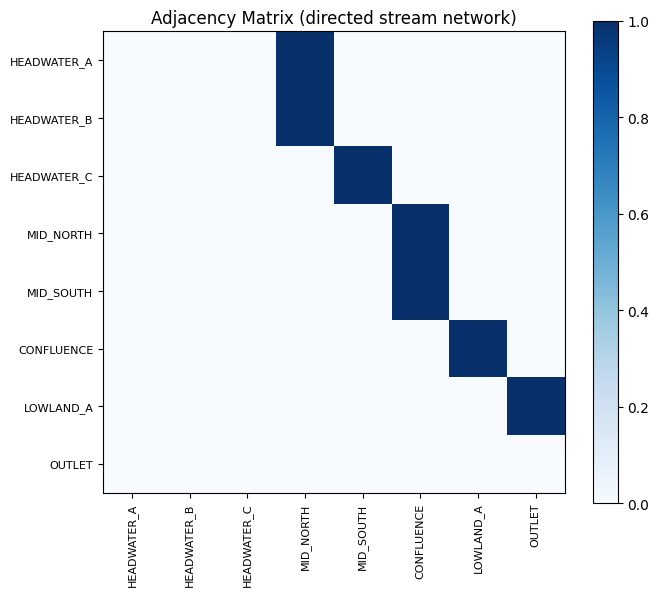

Graph properties:
  Is connected (weakly): True
  Diameter (longest shortest path): 4
  Longest path (DAG): ['HEADWATER_A', 'MID_NORTH', 'CONFLUENCE', 'LOWLAND_A', 'OUTLET']
  All paths from HEADWATER_A to OUTLET:
    HEADWATER_A -> MID_NORTH -> CONFLUENCE -> LOWLAND_A -> OUTLET


In [4]:
# Adjacency matrix
A = nx.to_numpy_array(G, nodelist=list(G.nodes()))
node_list = list(G.nodes())
fig, ax = plt.subplots(figsize=(7,6))
im = ax.imshow(A, cmap='Blues')
ax.set_xticks(range(len(node_list))); ax.set_xticklabels(node_list, rotation=90, fontsize=8)
ax.set_yticks(range(len(node_list))); ax.set_yticklabels(node_list, fontsize=8)
ax.set_title('Adjacency Matrix (directed stream network)')
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

# Graph-level properties
print(f"Graph properties:")
print(f"  Is connected (weakly): {nx.is_weakly_connected(G)}")
print(f"  Diameter (longest shortest path): {nx.diameter(G.to_undirected())}")
print(f"  Longest path (DAG): {nx.dag_longest_path(G)}")
print(f"  All paths from HEADWATER_A to OUTLET:")
for path in nx.all_simple_paths(G, 'HEADWATER_A', 'OUTLET'):
    print(f"    {' -> '.join(path)}")

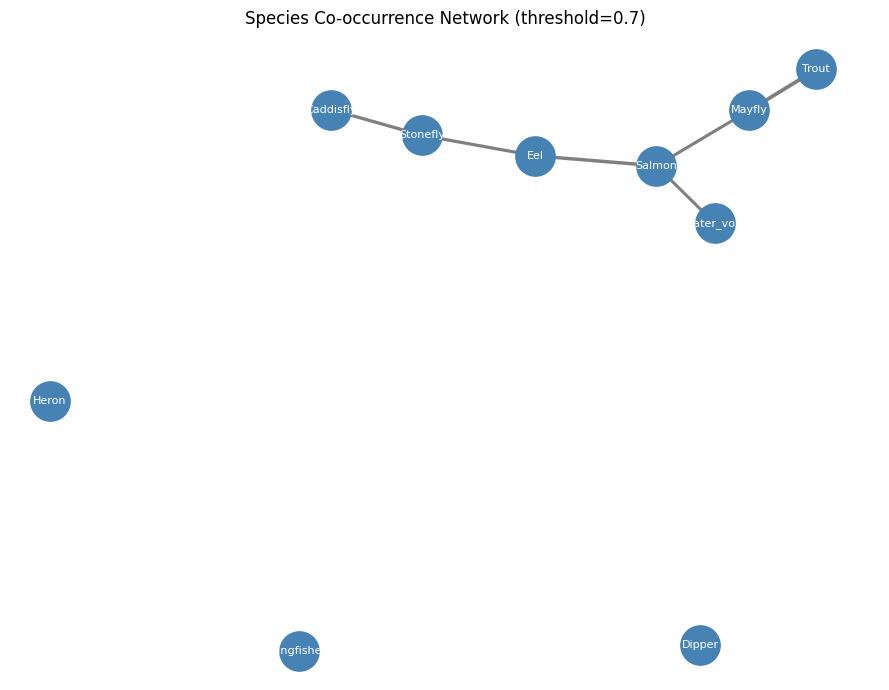

Co-occurrence network: 10 species, 6 edges


In [5]:
# Undirected species co-occurrence network
species = ['Salmon','Trout','Eel','Mayfly','Stonefly','Caddisfly',
           'Water_vole','Kingfisher','Heron','Dipper']
# Simulate co-occurrence matrix (correlation-like)
n_sp = len(species)
co_occ = rng.uniform(0.1, 1.0, (n_sp, n_sp))
co_occ = (co_occ + co_occ.T) / 2   # symmetric
np.fill_diagonal(co_occ, 0)
# Build graph: include only strong co-occurrences
G_sp = nx.Graph()
G_sp.add_nodes_from(species)
threshold = 0.7
for i in range(n_sp):
    for j in range(i+1, n_sp):
        if co_occ[i,j] > threshold:
            G_sp.add_edge(species[i], species[j], weight=co_occ[i,j])
pos_sp = nx.spring_layout(G_sp, seed=42)
fig, ax = plt.subplots(figsize=(9,7))
nx.draw_networkx(G_sp, pos=pos_sp, ax=ax,
    node_color='steelblue', node_size=800, font_size=8, font_color='white',
    edge_color='grey', width=[G_sp.edges[u,v]['weight']*3 for u,v in G_sp.edges()])
ax.set_title(f'Species Co-occurrence Network (threshold={threshold})')
ax.axis('off'); plt.tight_layout(); plt.show()
print(f"Co-occurrence network: {G_sp.number_of_nodes()} species, {G_sp.number_of_edges()} edges")

---

## Common Pitfalls

**1. Confusing directed and undirected graphs**  
In a directed graph (DiGraph), edge (A, B) is distinct from (B, A). Using `nx.Graph` for a directed process (stream flow, predation) silently loses directionality. Always choose the correct graph class upfront; converting later with `.to_directed()` or `.to_undirected()` may produce incorrect structure.

**2. Forgetting that `G.nodes()` and `G.edges()` return view objects, not lists**  
NetworkX node and edge views are live views of the graph. Modifying the graph while iterating over a view produces unpredictable results. Convert to a list first: `list(G.nodes())` or `list(G.edges(data=True))`.

**3. Building graphs from pandas DataFrames with duplicate edges**  
If the DataFrame has repeated (u, v) pairs and you use `nx.from_pandas_edgelist()`, duplicate edges are silently ignored in a `Graph` (last attribute wins) or added as parallel edges in a `MultiGraph`. Always check for duplicates before constructing the graph.

**4. Using spring layout for large graphs without a fixed seed**  
`nx.spring_layout()` is non-deterministic. Without `seed=`, every call produces a different layout, making visualisations unreproducible. Always set `seed=42` (or any integer) for reproducible layouts.

**5. Applying algorithms designed for undirected graphs to directed graphs without conversion**  
Functions like `nx.clustering()`, `nx.diameter()`, and community detection algorithms assume undirected graphs. Passing a DiGraph either raises an error or produces meaningless results. Always check the algorithm's requirements and convert with `.to_undirected()` when necessary.

---
*python_methods_library - Samantha McGarrigle*